<a href="https://colab.research.google.com/github/ghadirchhade/Master-Thesis/blob/main/E03_w_tiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [2]:
!pip install -q torch torchvision

In [3]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# facebook/sam3 is gated on the Hub -> you must accept the license at
# https://huggingface.co/facebook/sam3 with the account whose token you use below.
!pip install -q -U transformers accelerate huggingface_hub supervision

from huggingface_hub import login
login()  # paste your HF token (needs access to facebook/sam3)

print("Transformers SAM3 dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 8.0 MB/s eta 0:00:00
Transformers SAM3 dependencies installed.


In [6]:
import os
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import supervision as sv
import matplotlib.patches as patches
from transformers import Sam3Model, Sam3Processor

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sam3_model = Sam3Model.from_pretrained("facebook/sam3", device_map="auto")
sam3_model.eval()

sam3_processor = Sam3Processor.from_pretrained("facebook/sam3")

print("HF transformers SAM3 model + processor loaded.")
print("Model device:", next(sam3_model.parameters()).device)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

HF transformers SAM3 model + processor loaded.
Model device: cuda:0


In [8]:
IMAGE_PATH = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/images/20230426_Wallenwil/DJI_20230426110736_0035.JPG"
LABEL_PATH = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/annotations_yolo/DJI_20230426110736_0035.txt"
RUMEX_CLASS_ID = 0

target_image = Image.open(IMAGE_PATH).convert("RGB")
img_w, img_h = target_image.size
print(f"Target image size (W, H): {target_image.size}")

Target image size (W, H): (8192, 5460)


In [9]:
# ---- GT box loading (used ONLY for evaluation/visualization, not as model input) ----
def load_yolo_boxes(label_path, img_width, img_height, class_id=0):
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls != class_id:
                continue
            xc, yc, bw, bh = map(float, parts[1:5])
            xc, yc, bw, bh = xc * img_width, yc * img_height, bw * img_width, bh * img_height
            boxes.append([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2])
    return np.array(boxes, dtype=np.float32)

gt_boxes = load_yolo_boxes(LABEL_PATH, img_w, img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes)} GT box(es) with class id={RUMEX_CLASS_ID}.")

Loaded 57 GT box(es) with class id=0.


In [10]:
import matplotlib.font_manager as fm
font_path = fm.findfont("DejaVu Sans")
font = ImageFont.truetype(font_path, 100)

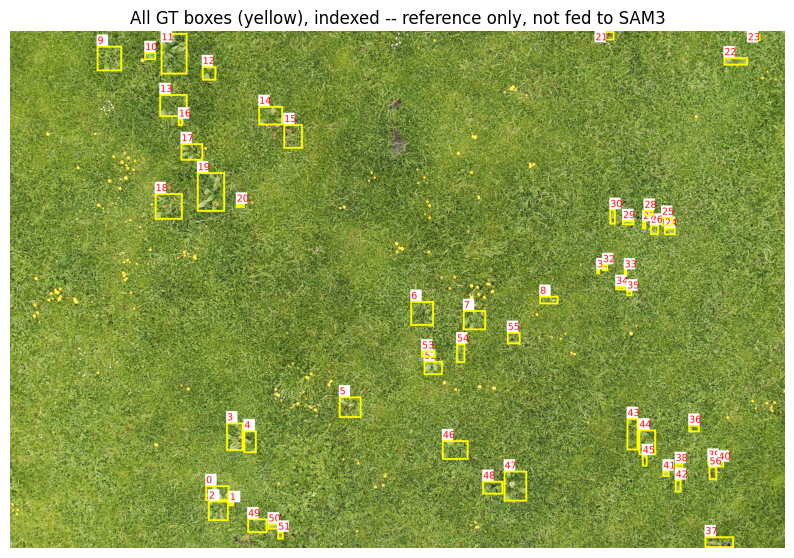

In [11]:
# Visualize all GT boxes (yellow), for reference only
gt_preview = target_image.copy()
draw = ImageDraw.Draw(gt_preview)

for i, (x0, y0, x1, y1) in enumerate(gt_boxes):
    draw.rectangle([x0, y0, x1, y1], outline=(255, 255, 0), width=20)
    text_x, text_y = int(x0), max(0, int(y0) - 120)
    draw.rectangle([text_x, text_y, text_x + 120, text_y + 120], fill=(255, 255, 255))
    draw.text((text_x + 10, text_y + 5), str(i), fill=(255, 0, 0), font=font)

plt.figure(figsize=(10, 8))
plt.imshow(gt_preview)
plt.title("All GT boxes (yellow), indexed -- reference only, not fed to SAM3")
plt.axis("off")
plt.show()

In [12]:
# TEXT PROMPT -- no exemplar crop, no compose_tile_with_exemplar step at all
text_prompt = "broad dock leaf, dark green oval leaf with crinkled wavy margins and reddish stem base, low rosette growth"


In [13]:
def tile_bboxes(img_w: int, img_h: int, tile_size: int, overlap: int):
    """
    Generates (x1,y1,x2,y2) windows covering the whole image, with overlap so plants
    sitting right on a tile boundary aren't missed or half-cut in every window.
    """
    step = tile_size - overlap
    tiles = []
    for y in range(0, img_h, step):
        for x in range(0, img_w, step):
            x2 = min(x + tile_size, img_w)
            y2 = min(y + tile_size, img_h)
            x1 = max(0, x2 - tile_size)
            y1 = max(0, y2 - tile_size)
            tiles.append((x1, y1, x2, y2))
    return list(dict.fromkeys(tiles))

In [14]:
def filter_implausible_boxes(boxes, scores, masks, tile_w, tile_h,
                              min_fill_ratio=0.15, max_area_fraction=0.6, edge_margin=5):
    """
    Drops detections unlikely to be real single Rumex plants:
      - box area implausibly large relative to the tile (likely background clutter,
        not a single plant)
      - predicted mask fills too little of its own box (weak/noisy detection rather
        than a confident, well-localized instance)
      - degenerate boxes clipped to (near) zero size at the tile edges
    """
    kept_boxes, kept_scores, kept_masks = [], [], []
    tile_area = tile_w * tile_h

    for box, score, mask in zip(boxes, scores, masks):
        x1, y1, x2, y2 = box
        box_w, box_h = x2 - x1, y2 - y1
        if box_w <= edge_margin or box_h <= edge_margin:
            continue

        box_area = box_w * box_h
        if box_area / tile_area > max_area_fraction:
            continue

        mask_np = mask.cpu().numpy() if torch.is_tensor(mask) else mask
        x1c, y1c = int(max(0, x1)), int(max(0, y1))
        x2c, y2c = int(min(mask_np.shape[1], x2)), int(min(mask_np.shape[0], y2))
        if x2c <= x1c or y2c <= y1c:
            continue

        region = mask_np[y1c:y2c, x1c:x2c]
        fill_ratio = (region > 0.5).mean() if region.size > 0 else 0.0
        if fill_ratio < min_fill_ratio:
            continue

        kept_boxes.append(box)
        kept_scores.append(score)
        kept_masks.append(mask)

    return kept_boxes, kept_scores, kept_masks

In [15]:
def run_sam3_on_tile_text_only(tile_img, text_prompt, threshold=0.3):
    #Pure text-prompt inference on a single tile -- no exemplar box, no compositing,
    #no offset/padding-strip bookkeeping needed since nothing is pasted onto the tile.

    inputs = sam3_processor(
        images=tile_img,
        text=text_prompt,
        return_tensors="pt",
    ).to(sam3_model.device)

    with torch.no_grad():
        outputs = sam3_model(**inputs)

    results = sam3_processor.post_process_instance_segmentation(
        outputs, threshold=threshold, mask_threshold=0.4,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]

    return results["boxes"], results["scores"], results["masks"]

In [16]:
def nms_merge(boxes, scores, masks, iou_thresh: float = 0.5):
    """
    Because tiles overlap, the same real plant can get detected in two neighboring
    tiles. Standard IoU-based Non-Max Suppression collapses duplicates down to the
    single highest-confidence box -- carries the matching mask through too.
    """
    if not boxes:
        return [], [], []

    boxes_t = torch.tensor(boxes, dtype=torch.float32)
    scores_t = torch.tensor([s.item() if torch.is_tensor(s) else s for s in scores])
    order = scores_t.argsort(descending=True)
    keep = []

    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]
        xx1 = torch.maximum(boxes_t[i, 0], boxes_t[rest, 0])
        yy1 = torch.maximum(boxes_t[i, 1], boxes_t[rest, 1])
        xx2 = torch.minimum(boxes_t[i, 2], boxes_t[rest, 2])
        yy2 = torch.minimum(boxes_t[i, 3], boxes_t[rest, 3])
        inter = (xx2 - xx1).clamp(0) * (yy2 - yy1).clamp(0)
        area_i = (boxes_t[i, 2] - boxes_t[i, 0]) * (boxes_t[i, 3] - boxes_t[i, 1])
        area_r = (boxes_t[rest, 2] - boxes_t[rest, 0]) * (boxes_t[rest, 3] - boxes_t[rest, 1])
        iou = inter / (area_i + area_r - inter + 1e-6)
        order = rest[iou <= iou_thresh]

    kept_boxes = [boxes[i] for i in keep]
    kept_scores = [scores[i] for i in keep]
    kept_masks = [masks[i] for i in keep]
    return kept_boxes, kept_scores, kept_masks

In [17]:
def show_image_with_boxes(image: Image.Image, boxes_xyxy, masks=None, scores=None,
                           gt_boxes_xyxy=None, title=""):
    """
    masks: list of (mask_np, ox, oy) tuples in TILE-local pixel space, placed at
    (ox, oy) in the full image via matplotlib's `extent` -- avoids ever building a
    full-image-sized mask array.
    """
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image)
    ax.set_xlim(0, image.width)
    ax.set_ylim(image.height, 0)

    rng = np.random.default_rng(0)

    if masks is not None:
        for (mask_np, ox, oy) in masks:
            color = rng.uniform(0.2, 1.0, size=3)
            mask_np = mask_np.cpu().numpy() if torch.is_tensor(mask_np) else mask_np
            h, w = mask_np.shape[:2]
            overlay = np.zeros((h, w, 4))
            overlay[mask_np > 0.5] = (*color, 0.45)
            ax.imshow(overlay, extent=[ox, ox + w, oy + h, oy])

    if gt_boxes_xyxy is not None:
        for gx1, gy1, gx2, gy2 in gt_boxes_xyxy:
            rect = patches.Rectangle(
                (gx1, gy1), gx2 - gx1, gy2 - gy1,
                linewidth=2, edgecolor="yellow", facecolor="none",
            )
            ax.add_patch(rect)

    for i, box in enumerate(boxes_xyxy):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        if scores is not None:
            ax.text(
                x1, y1 - 5, f"{scores[i]:.2f}",
                color="lime", fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"),
            )

    ax.set_title(title)
    ax.axis("off")
    plt.show()

Tile region in target image: (0, 0) -> (1000, 1000)
Tile size (W, H): (1000, 1000)


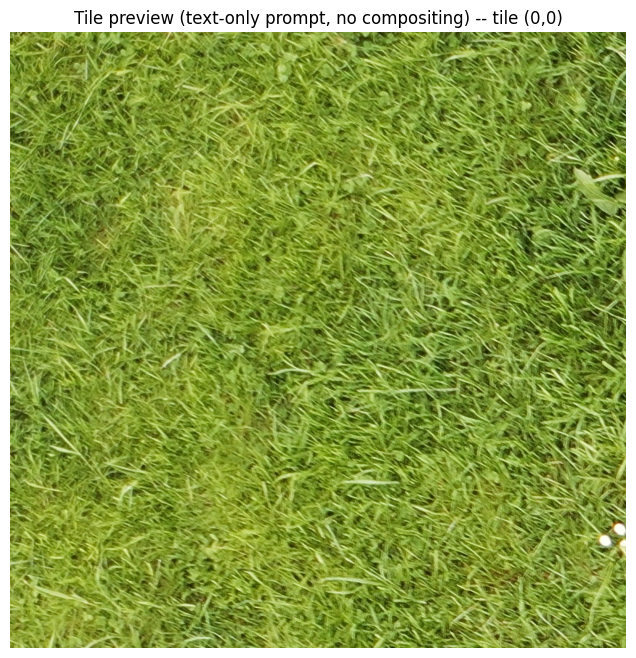

In [18]:
# ---- Preview one tile (no exemplar to auto-pick, so just preview the first tile) ----
TILE_SIZE = 1000
OVERLAP = 150

all_tiles = tile_bboxes(target_image.width, target_image.height, TILE_SIZE, OVERLAP)
preview_x1, preview_y1, preview_x2, preview_y2 = all_tiles[0]
preview_tile = target_image.crop((preview_x1, preview_y1, preview_x2, preview_y2))

print(f"Tile region in target image: ({preview_x1}, {preview_y1}) -> ({preview_x2}, {preview_y2})")
print(f"Tile size (W, H): {preview_tile.size}")

plt.figure(figsize=(8, 8))
plt.imshow(preview_tile)
plt.axis("off")
plt.title(f"Tile preview (text-only prompt, no compositing) -- tile ({preview_x1},{preview_y1})")
plt.show()

In [19]:
# ---- Main inference pipeline (text-only) ----
"""
Split the large drone image into overlapping tiles.
Run SAM3 on each RAW tile using only the text prompt (no exemplar compositing,
no offset/padding-strip bookkeeping since nothing is pasted onto the tile).
Remove implausible detections.
Convert tile-local detections back into original image coordinates.
Merge duplicate detections caused by tile overlap.
"""
all_boxes, all_scores, all_masks = [], [], []

for (x1, y1, x2, y2) in tile_bboxes(target_image.width, target_image.height, TILE_SIZE, OVERLAP):
    tile = target_image.crop((x1, y1, x2, y2))

    boxes, scores, masks = run_sam3_on_tile_text_only(
        tile, text_prompt=text_prompt, threshold=0.3,
    )

    tile_w, tile_h = x2 - x1, y2 - y1
    boxes, scores, masks = filter_implausible_boxes(
        boxes, scores, masks, tile_w, tile_h,
        min_fill_ratio=0.15, max_area_fraction=0.6, edge_margin=5,
    )

    for b, s, m in zip(boxes, scores, masks):
        b0, b1, b2, b3 = (b.tolist() if torch.is_tensor(b) else b)
        all_boxes.append([b0 + x1, b1 + y1, b2 + x1, b3 + y1])
        all_scores.append(s.item() if torch.is_tensor(s) else s)
        all_masks.append((m, x1, y1))

final_boxes, final_scores, final_masks = nms_merge(all_boxes, all_scores, all_masks, iou_thresh=0.5)

print(f"Total Rumex instances found: {len(final_boxes)}")
for i, (box, score) in enumerate(zip(final_boxes, final_scores)):
    print(f"  instance {i}: confidence={score:.3f}, box={[round(v, 1) for v in box]}")

Total Rumex instances found: 0


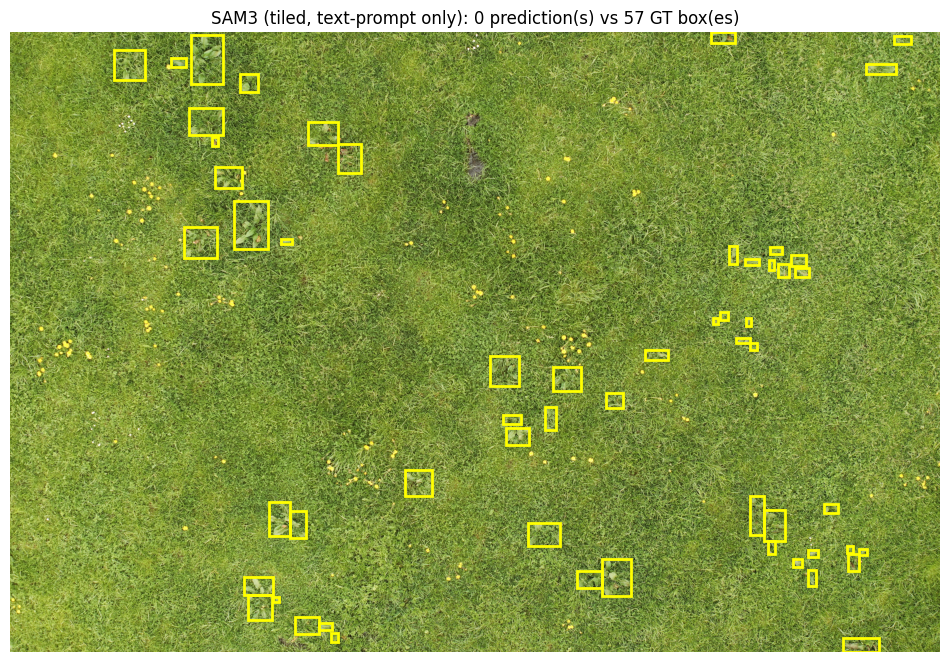

In [20]:
# ---- Display final predictions (lime) together with GT boxes (yellow) ----
show_image_with_boxes(
    target_image,
    boxes_xyxy=final_boxes,
    masks=final_masks,
    scores=final_scores,
    gt_boxes_xyxy=gt_boxes,
    title=f"SAM3 (tiled, text-prompt only): {len(final_boxes)} prediction(s) vs {len(gt_boxes)} GT box(es)",
)

In [21]:
#Compute detection metrics (box-based)
pred_boxes_np = np.array(final_boxes, dtype=np.float32) if final_boxes else np.zeros((0, 4), dtype=np.float32)
pred_scores_np = np.array(final_scores, dtype=np.float32) if final_scores else np.zeros((0,), dtype=np.float32)

pred_detections = sv.Detections(
    xyxy=pred_boxes_np,
    confidence=pred_scores_np,
    class_id=np.zeros(len(pred_scores_np), dtype=int),
)
gt_detections = sv.Detections(
    xyxy=gt_boxes,
    class_id=np.zeros(len(gt_boxes), dtype=int),
)

from supervision.metrics import MeanAveragePrecision

map_metric = MeanAveragePrecision()
result = map_metric.update([pred_detections], [gt_detections]).compute()
print(f"mAP50: {result.map50:.4f}")

def compute_iou_matrix(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])
    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    inter_area = inter_w * inter_h
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2[None, :] - inter_area
    return np.where(union_area > 0, inter_area / union_area, 0.0)

IOU_THRESHOLD = 0.5
iou_matrix = compute_iou_matrix(pred_boxes_np, gt_boxes)
num_preds, num_gt = len(pred_boxes_np), len(gt_boxes)

matched_gt = set()
true_positives = 0
matched_ious = []
pred_order = np.argsort(-pred_scores_np) if num_preds > 0 else []

for pred_idx in pred_order:
    if num_gt == 0:
        break
    best_gt_idx = np.argmax(iou_matrix[pred_idx])
    best_iou = iou_matrix[pred_idx, best_gt_idx]
    if best_iou >= IOU_THRESHOLD and best_gt_idx not in matched_gt:
        matched_gt.add(best_gt_idx)
        true_positives += 1
        matched_ious.append(best_iou)

false_positives = num_preds - true_positives
false_negatives = num_gt - true_positives
precision = true_positives / num_preds if num_preds > 0 else 0.0
recall = true_positives / num_gt if num_gt > 0 else 0.0
mean_iou_matched = float(np.mean(matched_ious)) if matched_ious else 0.0
mean_iou_all_gt = float(np.sum(matched_ious) / num_gt) if num_gt > 0 else 0.0

print(f"IoU threshold: {IOU_THRESHOLD}")
print(f"Num predictions: {num_preds} | Num GT boxes: {num_gt}")
print(f"True Positives:  {true_positives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Mean IoU (matched pairs only): {mean_iou_matched:.4f}")
print(f"Mean IoU (over all GT boxes):  {mean_iou_all_gt:.4f}")

mAP50: 0.0000
IoU threshold: 0.5
Num predictions: 0 | Num GT boxes: 57
True Positives:  0
False Positives: 0
False Negatives: 57
Precision: 0.0000
Recall:    0.0000
Mean IoU (matched pairs only): 0.0000
Mean IoU (over all GT boxes):  0.0000
